In [1]:
import numpy as np
import pandas as pd
import json
from IPython.display import Image, display
import os

In [2]:
pwd

'/data/users/ohenry/nova-times/measure_times_demo'

# This is a demonstration of how to use the nova-times tool. This notebook must be in the directory with your AAVSO .csv files.

## One source (e.g. V1324 Sco)

### try a one off analysis

In [3]:
your_filename = "aavsodata_V1324_SCO.csv"
out = !nova-times measure --algo interpolation -b V -N 2.0 {your_filename}

In [4]:
out # as is, the output is not very easy to parse

['{',
 '    "band": "V",',
 '    "algorithm": "interpolation",',
 '    "maximum_jd": 2456098.46888,',
 '    "maximum_mag": 9.868,',
 '    "N": "2.0",',
 '    "tN_mag": 11.873633857128617,',
 '    "tN_jd": 2456122.6355465767',
 '}']

In [5]:
json.loads("\n".join(out)) # make into dictionary by parsing the output json. way better. 

{'band': 'V',
 'algorithm': 'interpolation',
 'maximum_jd': 2456098.46888,
 'maximum_mag': 9.868,
 'N': '2.0',
 'tN_mag': 11.873633857128617,
 'tN_jd': 2456122.6355465767}

### interating over analyses by algorithim 

In [6]:
infilename = "aavsodata_V1324_SCO.csv"
algos = ["interpolation", "GBM", "nearest_point"]

results = {}

for algo in algos:
    out = !nova-times measure --algo {algo} -b V -N 2.0 {infilename}
    results[algo] = json.loads("\n".join(out)) # dict keyed by algo name rather than a numeric index

In [8]:
results

{'interpolation': {'band': 'V',
  'algorithm': 'interpolation',
  'maximum_jd': 2456098.46888,
  'maximum_mag': 9.868,
  'N': '2.0',
  'tN_mag': 11.873633857128617,
  'tN_jd': 2456122.6355465767},
 'GBM': {'band': 'V',
  'algorithm': 'GBM',
  'maximum_jd': 2456098.46888,
  'maximum_mag': 9.868,
  'N': '2.0',
  'tN_mag': 11.979709089513317,
  'tN_jd': 2456122.6355465767},
 'nearest_point': {'band': 'V',
  'algorithm': 'nearest_point',
  'maximum_jd': 2456098.46888,
  'maximum_mag': 9.868,
  'N': '2.0',
  'tN_mag': 11.977,
  'tN_jd': 2456122.7636}}

### interating over analyses by band 

In [9]:
infilename = "aavsodata_V1324_SCO.csv"
algorithim = "GBM"
bands = ["V", "B", "CV"]

results = {}

for band in bands:
    out = !nova-times measure --algo {algorithim} -b {band} -N 2.0 {infilename}
    results[band] = json.loads("\n".join(out))

In [10]:
results

{'V': {'band': 'V',
  'algorithm': 'GBM',
  'maximum_jd': 2456098.46888,
  'maximum_mag': 9.868,
  'N': '2.0',
  'tN_mag': 11.979709089513317,
  'tN_jd': 2456122.6355465767},
 'B': {'band': 'B',
  'algorithm': 'GBM',
  'maximum_jd': 2456098.19012,
  'maximum_mag': 11.163,
  'N': '2.0',
  'tN_mag': 13.600959044496122,
  'tN_jd': 2456121.898453245},
 'CV': {'band': 'CV',
  'algorithm': 'GBM',
  'maximum_jd': 2456098.01,
  'maximum_mag': 8.9844,
  'N': '2.0',
  'tN_mag': 9.395172229084219,
  'tN_jd': 2456100.63499999}}

In [11]:
tN = results['V']['tN_jd'] - results['V']['maximum_jd'] #this is your "tN" measurment
print(np.round(tN, 2))

24.17


## Try to make and view plots of our fit results and measurments

### all we need to add to our previous commands is the make_plots (boolean) and the limits (boolean) keywords and a way to display the plots that are being saved.

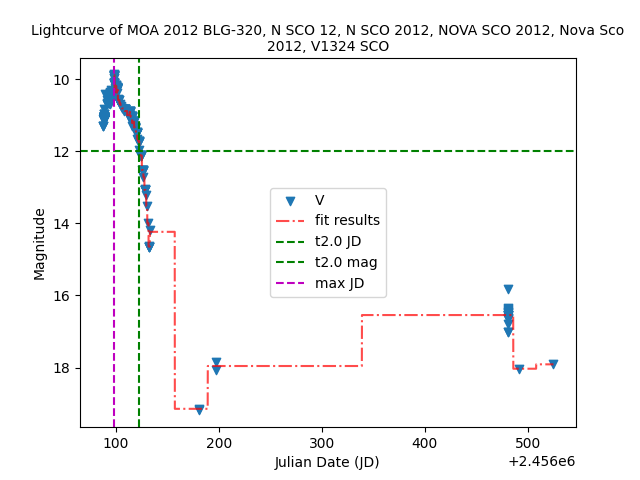

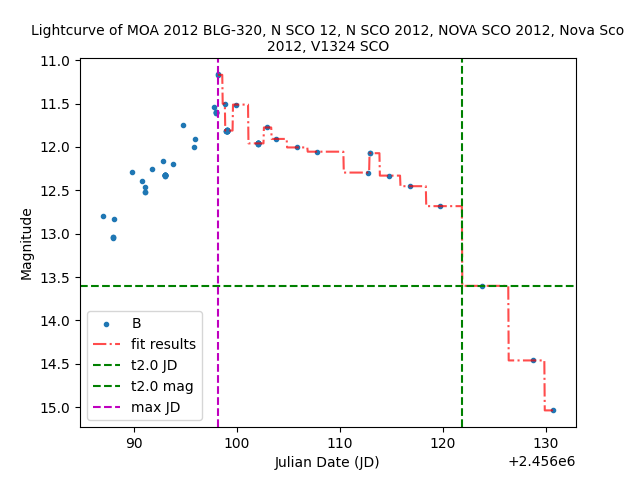

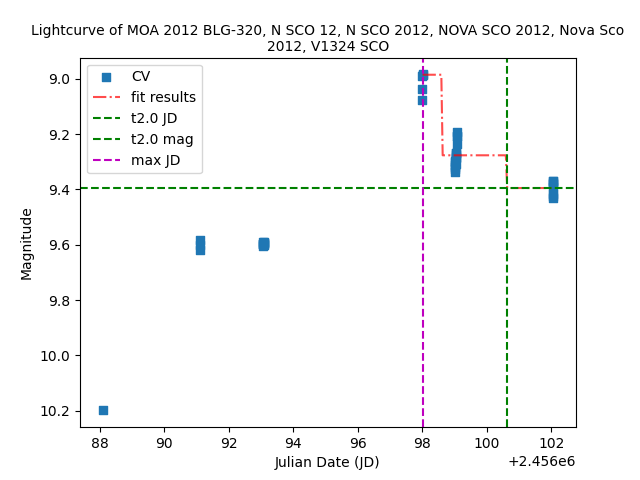

In [12]:
infilename = "aavsodata_V1324_SCO.csv"
algorithim = "GBM"
bands = ["V", "B", "CV"]

results = {}

for band in bands:
    out = !nova-times measure --algo {algorithim} -b {band} -N 2.0 -mp True -out {band}_lightcurve_.png {infilename}
    results[band] = json.loads("\n".join(out)) # dict keyed by algo name rather than a numeric index
    display(Image(filename=f"{band}_lightcurve_.png"))

In [13]:
results

{'V': {'band': 'V',
  'algorithm': 'GBM',
  'maximum_jd': 2456098.46888,
  'maximum_mag': 9.868,
  'N': '2.0',
  'tN_mag': 11.979709089513317,
  'tN_jd': 2456122.6355465767},
 'B': {'band': 'B',
  'algorithm': 'GBM',
  'maximum_jd': 2456098.19012,
  'maximum_mag': 11.163,
  'N': '2.0',
  'tN_mag': 13.600959044496122,
  'tN_jd': 2456121.898453245},
 'CV': {'band': 'CV',
  'algorithm': 'GBM',
  'maximum_jd': 2456098.01,
  'maximum_mag': 8.9844,
  'N': '2.0',
  'tN_mag': 9.395172229084219,
  'tN_jd': 2456100.63499999}}

### to see the entire lightcurve with all bands we simply use the viz function in the following way

In [14]:
your_filename = "aavsodata_V1324_SCO.csv"
output_filename = 'entire_lightcurve.png'
!nova-times viz {your_filename} {output_filename}

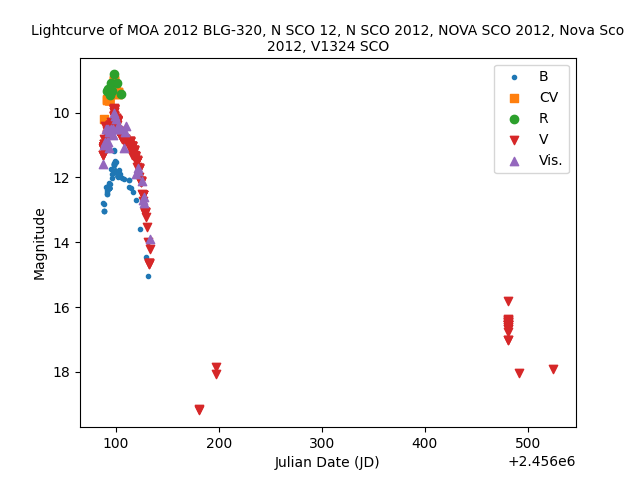

In [15]:
display(Image(filename=output_filename))

## Analysing many sources

In [16]:
infilenames = ["aavsodata_V1324_SCO.csv", "aavsodata_V1716_SCO.csv", 
               "aavsodata_V1723_SCO.csv", "aavsodata_V5855_SGR.csv"] #names of your .csv files from AAVSO 

names = ['V1324 Sco', 'V1716 Sco', 'V1723 Sco', 'V5855 Sgr']
algo = "GBM"

results = {}

for name, file in zip(names, infilenames):
    out = !nova-times measure --algo {algo} -b V -N 2.0 {file}
    results[name] = json.loads("\n".join(out)) # dict keyed by algo name rather than a numeric index

In [17]:
results

{'V1324 Sco': {'band': 'V',
  'algorithm': 'GBM',
  'maximum_jd': 2456098.46888,
  'maximum_mag': 9.868,
  'N': '2.0',
  'tN_mag': 11.979709089513317,
  'tN_jd': 2456122.6355465767},
 'V1716 Sco': {'band': 'V',
  'algorithm': 'GBM',
  'maximum_jd': 2460056.625,
  'maximum_mag': 6.777,
  'N': '2.0',
  'tN_mag': 8.759763738038767,
  'tN_jd': 2460060.1666666535},
 'V1723 Sco': {'band': 'V',
  'algorithm': 'GBM',
  'maximum_jd': 2460351.29054,
  'maximum_mag': 6.773,
  'N': '2.0',
  'tN_mag': 8.78831205340185,
  'tN_jd': 2460360.165539967},
 'V5855 Sgr': {'band': 'V',
  'algorithm': 'GBM',
  'maximum_jd': 2457691.56544,
  'maximum_mag': 7.748,
  'N': '2.0',
  'tN_mag': 10.43994938991056,
  'tN_jd': 2457703.6487732884}}

### Vizualizing multi-band lightcurves for many sources

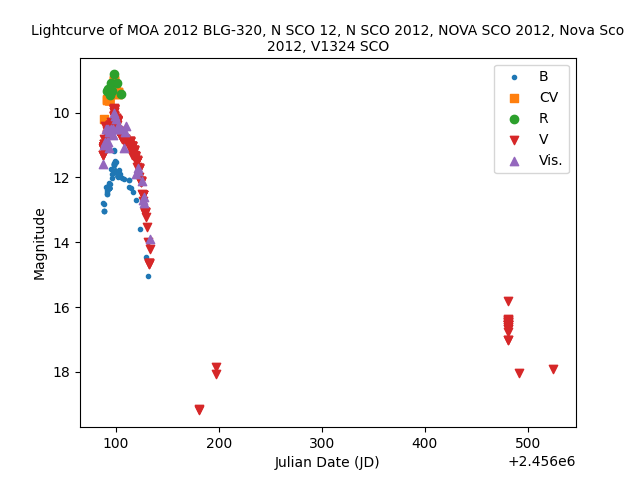

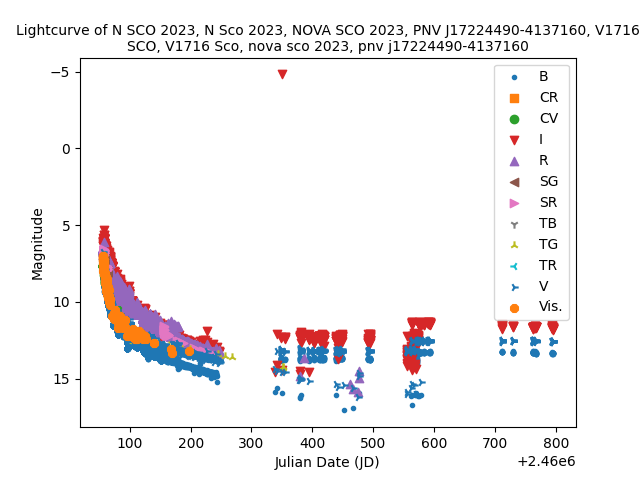

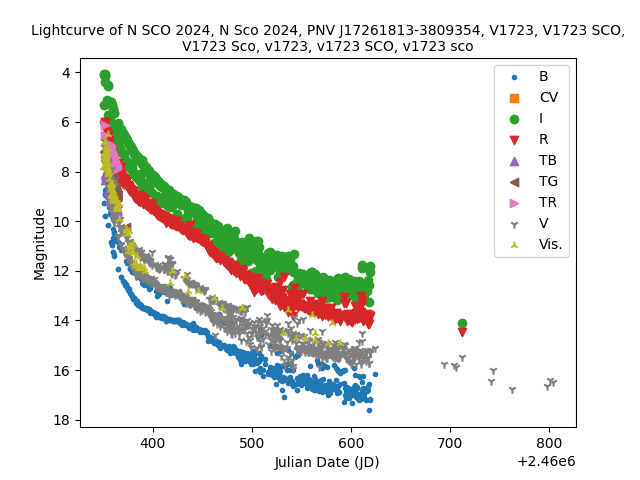

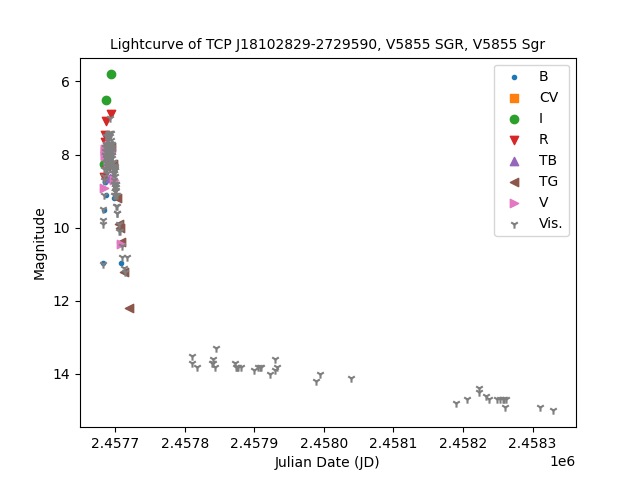

In [18]:
infilenames = ["aavsodata_V1324_SCO.csv", "aavsodata_V1716_SCO.csv", 
               "aavsodata_V1723_SCO.csv", "aavsodata_V5855_SGR.csv"] #names of your .csv files from AAVSO 

names = ['V1324Sco', 'V1716Sco', 'V1723Sco', 'V5855Sgr']

for name, file in zip(names, infilenames):
    your_filename = file
    output_filename = f"{name}_lightcurve.png"
    !nova-times viz {your_filename} {output_filename}
    display(Image(filename=f"{name}_lightcurve.png"))